C:\Users\walcker\AppData\Local\Temp\ipykernel_22124\3791758396.py:66: RuntimeWarning: All-NaN slice encountered
  min_by_latitude = np.nanmin(raw_data, axis=1)
C:\Users\walcker\AppData\Local\Temp\ipykernel_22124\3791758396.py:67: RuntimeWarning: All-NaN slice encountered
  max_by_latitude = np.nanmax(raw_data, axis=1)


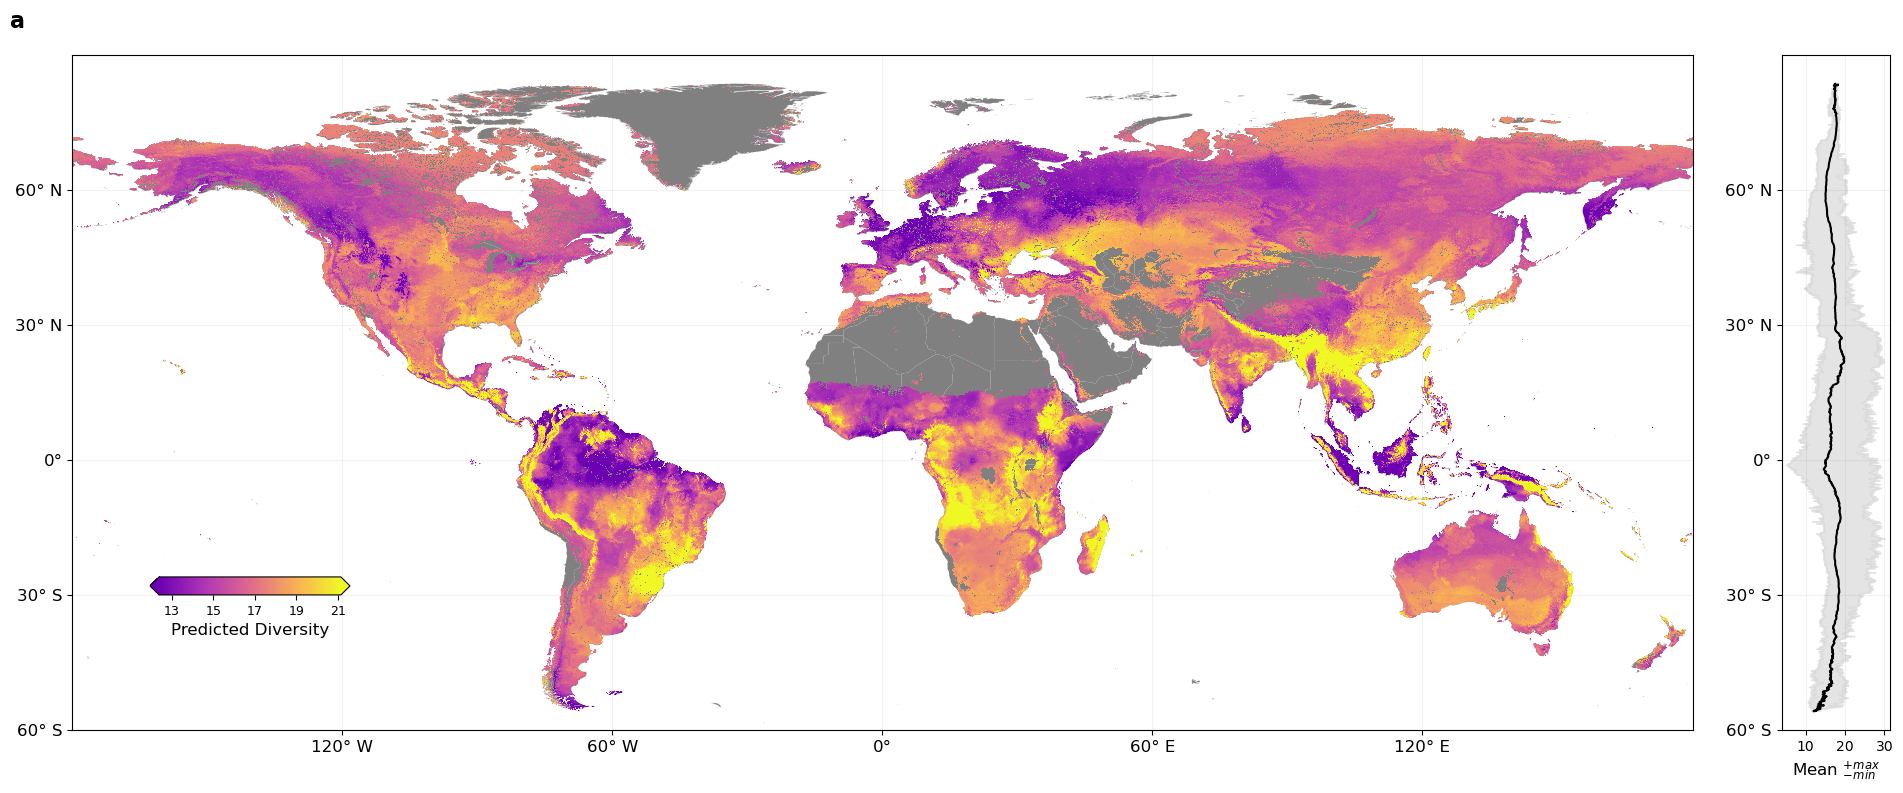

In [3]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import geopandas as gpd
import matplotlib.gridspec as gridspec
import warnings

# Masquer les RuntimeWarnings de NumPy liés aux calculs de statistiques vides
warnings.filterwarnings('ignore', message='Mean of empty slice')
warnings.filterwarnings('ignore', message='Degrees of freedom <= 0 for slice.')

# Définir le chemin du fichier raster ---
file_path = r"G:\Amibatec\Updated2025\RF\Diversity\imageToDrive_meanModel_Diversity_RF.tif"
world_boundaries_shp = r"G:\Amibatec\Updated2025\world-administrative-boundaries.shp"

# Définir une palette de couleurs personnalisée ---
colors = [
    "#6E00B3",  # Violet profond (Min)
    "#AF36B5",  # Magenta
    "#E0698C",  # Rouge-rose
    "#F9AE57",  # Orange vif
    "#F0F824"   # Jaune-blanc lumineux (Max)
]
cmap_name = 'CustomDiversityMap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=256)

with rasterio.open(file_path) as src:
    # Lire la première bande de données
    raw_data = src.read(1)

    # Gérer les valeurs NoData
    if src.nodata is not None:
        data[data == src.nodata] = np.nan
    data_for_stats = np.copy(raw_data)
    data_for_stats[data_for_stats == 0] = np.nan

    #min_val = np.nanmin(data_for_stats)
    #print('min = ', min_val)
    #max_val = np.nanmax(data_for_stats)
    #print('max = ', max_val)

    # Amélioration du contraste avec l'écart-type
    valid_data_stats = data_for_stats[~np.isnan(data_for_stats)]
    if valid_data_stats.size == 0:
        mean_val, std_val = 0, 1
        min_data_val, max_data_val = 5, 31
    else:
        mean_val = np.mean(valid_data_stats)
        std_val = np.std(valid_data_stats)
        min_data_val = np.nanmin(data_for_stats)
        max_data_val = np.nanmax(data_for_stats)

    num_std = 2
    vmin_contrast = max(min_data_val, mean_val - num_std * std_val)
    vmax_contrast = min(max_data_val, mean_val + num_std * std_val)
    min_val, max_val = vmin_contrast, vmax_contrast

    # Les valeurs en dehors de [vmin_contrast, vmax_contrast] seront clippées par la colormap.
    min_val, max_val = vmin_contrast, vmax_contrast 

    # Calcul des statistiques latitudinales (dans l'ordre du raster)
    mean_by_latitude = np.nanmean(raw_data, axis=1)
    std_by_latitude = np.nanstd(raw_data, axis=1)
    min_by_latitude = np.nanmin(raw_data, axis=1)
    max_by_latitude = np.nanmax(raw_data, axis=1)
    
    height = src.height
    transform = src.transform
    
    latitudes = np.array([transform * (0, i) for i in range(height)])[:, 1]
    
    # Inversion conditionnelle (si nécessaire)
    # On vérifie si les latitudes sont décroissantes (tête en bas)
    if latitudes[0] > latitudes[-1]:
        latitudes = latitudes[::-1]        # INVERSION : Latitudes
        mean_by_latitude = mean_by_latitude[::-1]
        std_by_latitude = std_by_latitude[::-1]
        min_by_latitude = min_by_latitude[::-1]
        max_by_latitude = max_by_latitude[::-1]

    # Définir les limites de l'aire
    #lower_bound = mean_by_latitude - 2 * std_by_latitude
    #upper_bound = mean_by_latitude + 2 * std_by_latitude
    lower_bound = min_by_latitude
    upper_bound = max_by_latitude

    # Création d'une figure
    fig = plt.figure(figsize=(20, 9))
    fig.text(x=0.03, y=0.95, s='a', fontsize=16,fontweight='bold',ha='left',va='top')

    # Définir la grille: 1 ligne, 2 colonnes
    # 'width_ratios' ajuste les largeurs relatives des colonnes
    gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[15, 1],wspace=0.1, hspace=0.0) # wspace: espace entre les colonnes
    ax_map = fig.add_subplot(gs[0, 0])
    ax_profile = fig.add_subplot(gs[0, 1], sharey=ax_map)

    # Affichage de la carte (ax_map)
    world = gpd.read_file(world_boundaries_shp)
    world = world.to_crs(src.crs)
    world.plot(ax=ax_map, color='grey', edgecolor='none', zorder=0)

    image = show(
        raw_data,
        transform=src.transform,
        ax=ax_map,
        cmap=custom_cmap,
        vmin=min_val,
        vmax=max_val,
        interpolation='nearest',
        zorder=1
    )

    # Personnalisation des labels des axes pour la carte
    lat_ticks = [-60, -30, 0, 30, 60]
    lat_labels = ['60° S', '30° S', '0°', '30° N','60° N']
    ax_map.set_yticks(lat_ticks)
    ax_map.set_yticklabels(lat_labels, fontsize=12)
    lon_ticks = [-120, -60, 0, 60, 120]
    lon_labels = ['120° W', '60° W', '0°', '60° E', '120° E']
    ax_map.set_xticks(lon_ticks)
    ax_map.set_xticklabels(lon_labels, fontsize=12)
    ax_map.grid(True, linestyle='-', alpha=0.1, color='grey')
    ax_map.set_ylim(-60, 90)
    ax_map.tick_params(axis='y', labelleft=True, left=True)

    # --- Configuration de la colorbar ---
    cbar_ax = fig.add_axes([0.10, 0.30, 0.10, 0.02])
    cbar = fig.colorbar(
        image.get_images()[0], 
        cax=cbar_ax, 
        orientation='horizontal',
        extend='both')
    
    cbar.set_label('Predicted Diversity', fontsize=12)
    cbar.ax.tick_params(labelsize=9)
    cbar_ticks = [13, 15, 17, 19, 21]
    cbar.set_ticks(cbar_ticks)

    # Définir le fond pour les océans (blanc)
    ax_map.set_facecolor('white')
    fig.patch.set_facecolor('white')

    # Partie 2: Affichage du profil de richesse par latitude
    # Tracer l'aire grisée de 2 écarts-types ---
    ax_profile.fill_betweenx(
        latitudes,
        lower_bound,
        upper_bound,
        color='lightgrey',
        alpha=0.6,
        label=r'$\pm 2\sigma$ range'
    )
    
    ax_profile.plot(mean_by_latitude, latitudes, color='black', linewidth=1.5)
    ax_profile.set_xlabel(r'Mean $^{+max}_{-min}$', fontsize=12)
    ax_profile.grid(True, linestyle='-', alpha=0.1, color='grey')
    ax_profile.set_yticklabels(lat_labels, fontsize=12)
    
    fig.subplots_adjust(left=0.06, right=0.97, top=0.9, bottom=0.15) # Ajustez ces valeurs

    # Save figure
    plt.savefig(r'G:\Amibatec\Updated2025\RF\Diversity\MapDiversity.jpeg', dpi=600, bbox_inches='tight')
    plt.show()

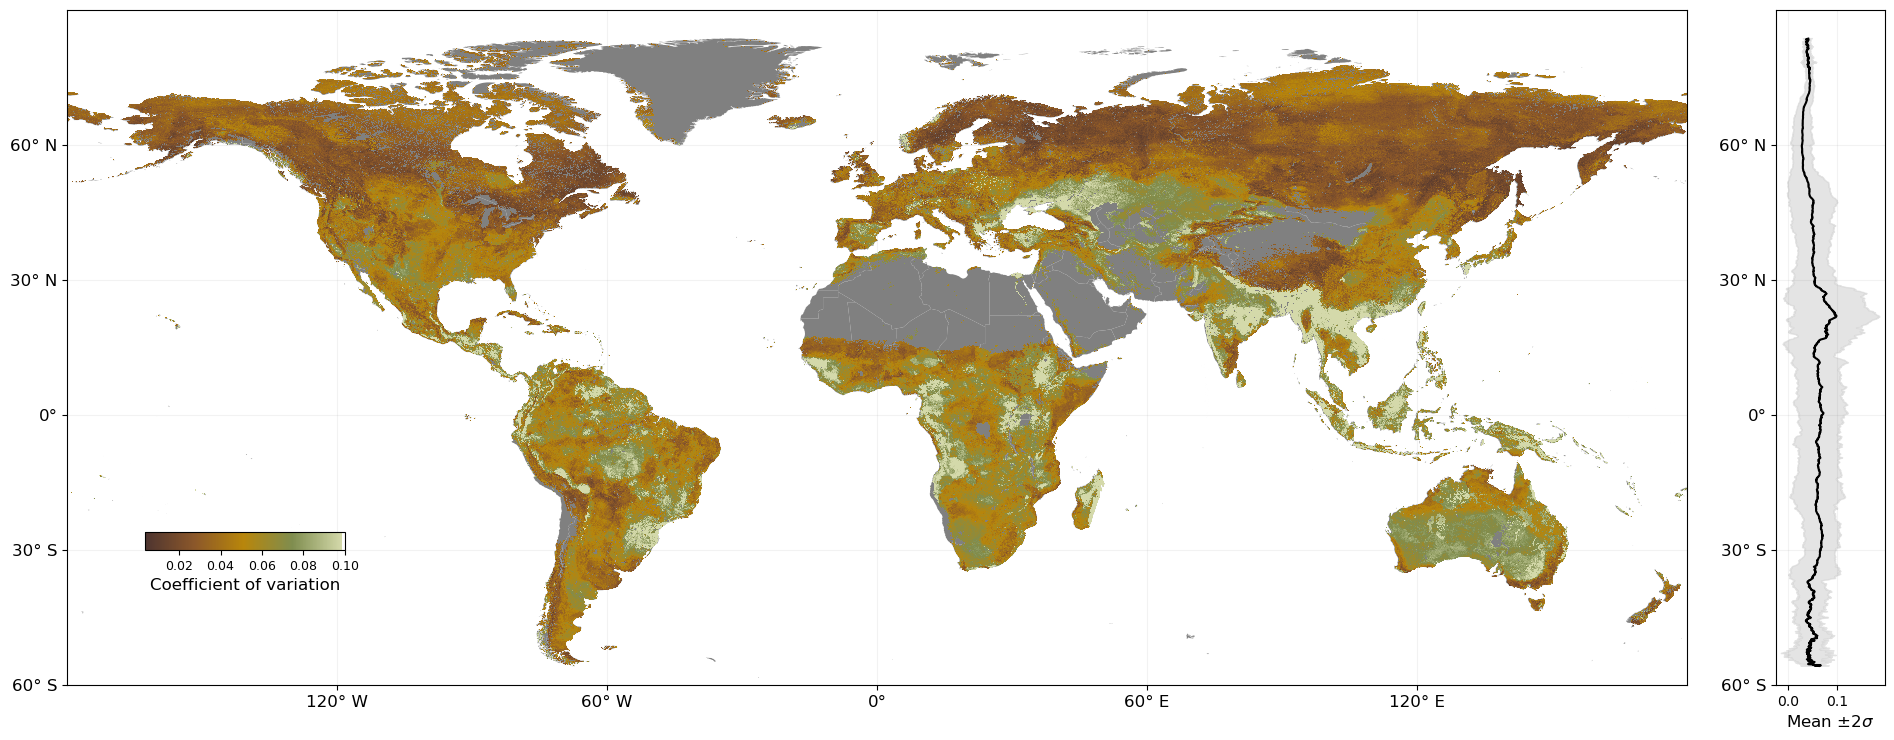

In [5]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import geopandas as gpd
import matplotlib.gridspec as gridspec
import warnings

# Masquer les RuntimeWarnings de NumPy liés aux calculs de statistiques vides
warnings.filterwarnings('ignore', message='Mean of empty slice')
warnings.filterwarnings('ignore', message='Degrees of freedom <= 0 for slice.')

# Définir le chemin du fichier raster ---
file_path = r"G:\Amibatec\Updated2025\RF\Diversity\imageToDrive_varCoefModel_Diversity_RF.tif"
world_boundaries_shp = r"G:\Amibatec\Updated2025\world-administrative-boundaries.shp"

# Définir une palette de couleurs personnalisée ---
colors = [
    "#4D3430",  # Marron Terreux Foncée (Faible richesse)
    "#8B572A",  # Brun Cuivré
    "#B8860B",  # Ocre Doré
    "#7F8D4F",  # Vert Sauge
    "#D4D9AA"   # Beige Pâle/Crème (Haute richesse)
]
cmap_name = 'CustomDiversityMap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=256)

with rasterio.open(file_path) as src:
    # Lire la première bande de données
    raw_data = src.read(1)

    # Gérer les valeurs NoData
    if src.nodata is not None:
        data[data == src.nodata] = np.nan
    data_for_stats = np.copy(raw_data)
    data_for_stats[data_for_stats == 0] = np.nan

    # Amélioration du contraste avec l'écart-type
    valid_data_stats = data_for_stats[~np.isnan(data_for_stats)]
    if valid_data_stats.size == 0:
        mean_val, std_val = 0, 1
        min_data_val, max_data_val = 0, 1
    else:
        mean_val = np.mean(valid_data_stats)
        std_val = np.std(valid_data_stats)
        min_data_val = np.nanmin(data_for_stats)
        max_data_val = np.nanmax(data_for_stats)

    num_std = 2
    vmin_contrast = max(min_data_val, mean_val - num_std * std_val)
    vmax_contrast = min(max_data_val, mean_val + num_std * std_val)
    min_val, max_val = vmin_contrast, vmax_contrast

    # Les valeurs en dehors de [vmin_contrast, vmax_contrast] seront clippées par la colormap.
    min_val, max_val = vmin_contrast, vmax_contrast 

    # Calcul des statistiques latitudinales (dans l'ordre du raster)
    mean_by_latitude = np.nanmean(raw_data, axis=1)
    std_by_latitude = np.nanstd(raw_data, axis=1) # Calcul de l'écart-type
    
    height = src.height
    transform = src.transform
    
    latitudes = np.array([transform * (0, i) for i in range(height)])[:, 1]
    
    # Inversion conditionnelle (si nécessaire)
    # On vérifie si les latitudes sont décroissantes (tête en bas)
    if latitudes[0] > latitudes[-1]:
        latitudes = latitudes[::-1]        # INVERSION : Latitudes
        mean_by_latitude = mean_by_latitude[::-1] # INVERSION : Moyenne
        std_by_latitude = std_by_latitude[::-1]   # INVERSION : Écart-type (pour alignement)

    # Définir les limites de l'aire (avec les données désormais alignées)
    lower_bound = mean_by_latitude - 2 * std_by_latitude
    upper_bound = mean_by_latitude + 2 * std_by_latitude

    # Création d'une figure
    fig = plt.figure(figsize=(20, 9)) # Taille de la figure globale

    # Définir la grille: 1 ligne, 2 colonnes
    # 'width_ratios' ajuste les largeurs relatives des colonnes
    gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[15, 1],wspace=0.1, hspace=0.0) # wspace: espace entre les colonnes
    ax_map = fig.add_subplot(gs[0, 0])
    ax_profile = fig.add_subplot(gs[0, 1], sharey=ax_map)

    # Affichage de la carte (ax_map)
    world = gpd.read_file(world_boundaries_shp)
    world = world.to_crs(src.crs)
    world.plot(ax=ax_map, color='grey', edgecolor='none', zorder=0)

    image = show(
        raw_data,
        transform=src.transform,
        ax=ax_map,
        cmap=custom_cmap,
        vmin=min_val,
        vmax=max_val,
        interpolation='nearest',
        zorder=1
    )

    # Personnalisation des labels des axes pour la carte
    lat_ticks = [-60, -30, 0, 30, 60]
    lat_labels = ['60° S', '30° S', '0°', '30° N','60° N']
    ax_map.set_yticks(lat_ticks)
    ax_map.set_yticklabels(lat_labels, fontsize=12)
    lon_ticks = [-120, -60, 0, 60, 120]
    lon_labels = ['120° W', '60° W', '0°', '60° E', '120° E']
    ax_map.set_xticks(lon_ticks)
    ax_map.set_xticklabels(lon_labels, fontsize=12)
    ax_map.grid(True, linestyle='-', alpha=0.1, color='grey')
    ax_map.set_ylim(-60, 90)
    ax_map.tick_params(axis='y', labelleft=True, left=True)

    # --- Configuration de la colorbar ---
    cbar_ax = fig.add_axes([0.10, 0.30, 0.10, 0.02])
    cbar = fig.colorbar(image.get_images()[0], cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Coefficient of variation', fontsize=12)
    cbar.ax.tick_params(labelsize=9)
    cbar_ticks = [0.02, 0.04, 0.06,0.08]
    cbar.set_ticks(cbar_ticks)

    # Définir le fond pour les océans (blanc)
    ax_map.set_facecolor('white')
    fig.patch.set_facecolor('white')

    # Partie 2: Affichage du profil de richesse par latitude
    # Tracer l'aire grisée de 2 écarts-types ---
    ax_profile.fill_betweenx(
        latitudes,              # Axe Y (Latitudes)
        lower_bound,            # Limite inférieure (X1)
        upper_bound,            # Limite supérieure (X2)
        color='lightgrey',      # Couleur
        alpha=0.6,              # Transparence
        label=r'$\pm 2\sigma$ range' # Légende (pour une éventuelle légende)
    )
    
    ax_profile.plot(mean_by_latitude, latitudes, color='black', linewidth=1.5)
    ax_profile.set_xlabel(r'Mean $\pm 2\sigma$', fontsize=12)
    ax_profile.grid(True, linestyle='-', alpha=0.1, color='grey')
    ax_profile.set_yticklabels(lat_labels, fontsize=12)
    
    fig.subplots_adjust(left=0.06, right=0.97, top=0.9, bottom=0.15) # Ajustez ces valeurs

    # Save figure
    plt.savefig(r'G:\Amibatec\Updated2025\RF\Diversity\MapDiversityCoefVar.jpeg', dpi=600, bbox_inches='tight')
    plt.show()